In [57]:

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [2]:
df = pd.read_csv(
    r"C:\Users\LENOVO\Documents\Nedbankassessment\bank_marketing_data.csv",
    sep=";"
)

df.head()

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target,post_campaign_action
0,0,30,unemployed,married,primary,no,1787.0,no,no,cellular,19,oct,79,1,-1,0,unknown,no,0
1,1,33,services,married,secondary,no,4789.0,yes,yes,cellular,11,may,220,1,339,4,failure,no,0
2,2,35,management,single,tertiary,no,1350.0,yes,no,cellular,16,apr,185,1,330,1,failure,no,0
3,3,30,management,married,tertiary,no,1476.0,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,0
4,4,59,blue-collar,married,secondary,no,0.0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,0


In [ ]:
df = pd.read_csv(
    r"C:\Users\LENOVO\Documents\Nedbankassessment\bank_marketing_data.csv",
    sep=";"
)

df.head()
df = df.drop(columns=["Unnamed: 0"])
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)
(df == "unknown").sum()
categorical_cols = ["job","education","contact"]

for col in categorical_cols:
    df[col] = df[col].fillna("unknown")
df["job"] = df["job"].fillna("unknown")
df["education"] = df["education"].fillna("unknown")
df["contact"] = df["contact"].fillna("unknown")
df["poutcome"] = df["poutcome"].fillna("unknown")
df["balance"] = df["balance"].fillna(df["balance"].median())
(df.isnull().sum() / len(df)) * 100
def clean_data(df):

    df = df.copy()

    # remove duplicates
    df = df.drop_duplicates()

    # check missing
    print(df.isnull().sum())

    # drop columns not available before campaign
    # duration should not be used in real predictions
    if "duration" in df.columns:
        df = df.drop(columns=["duration"])

    return df

df = clean_data(df)

# --------------------------------------------
# 3. TARGET VARIABLE DISTRIBUTION
# --------------------------------------------

def plot_target_distribution(df):

    plt.figure(figsize=(6,4))

    sns.countplot(x="target", data=df)

    plt.title("Campaign Response Distribution")
    plt.xlabel("Response")
    plt.ylabel("Count")

    plt.show()

    # Show percentage distribution
    print(df["target"].value_counts(normalize=True))

In [3]:
df['day'].min(), df['day'].max()

(1, 31)

## Clean Data

In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
## null and missing variables 
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

education               3.000438
balance                 2.956636
contact                 2.912834
job                     1.949190
age                     0.000000
duration                0.000000
target                  0.000000
poutcome                0.000000
previous                0.000000
pdays                   0.000000
campaign                0.000000
day                     0.000000
month                   0.000000
loan                    0.000000
housing                 0.000000
default                 0.000000
marital                 0.000000
post_campaign_action    0.000000
dtype: float64

In [6]:
(df == "unknown").sum()

age                        0
job                      127
marital                    0
education                178
default                    0
balance                    0
housing                    0
loan                       0
contact                 1391
day                        0
month                      0
duration                   0
campaign                   0
pdays                      0
previous                   0
poutcome                3787
target                     0
post_campaign_action       0
dtype: int64

In [7]:
categorical_cols = ["job","education","contact"]

for col in categorical_cols:
    df[col] = df[col].fillna("unknown")

In [8]:
df["job"] = df["job"].fillna("unknown")
df["education"] = df["education"].fillna("unknown")
df["contact"] = df["contact"].fillna("unknown")
df["poutcome"] = df["poutcome"].fillna("unknown")

In [9]:
df["balance"] = df["balance"].fillna(df["balance"].median())

In [10]:
(df.isnull().sum() / len(df)) * 100

age                     0.0
job                     0.0
marital                 0.0
education               0.0
default                 0.0
balance                 0.0
housing                 0.0
loan                    0.0
contact                 0.0
day                     0.0
month                   0.0
duration                0.0
campaign                0.0
pdays                   0.0
previous                0.0
poutcome                0.0
target                  0.0
post_campaign_action    0.0
dtype: float64

In [11]:
df["marital"].unique()

array(['married', 'single', 'divorced'], dtype=object)

In [12]:
df["education"].unique()

array(['primary', 'secondary', 'tertiary', 'unknown'], dtype=object)

In [13]:
df["default"].unique()

array(['no', 'yes'], dtype=object)

In [14]:

def clean_data(df):

    df = df.copy()

    # remove duplicates
    df = df.drop_duplicates()

    # check missing
    print(df.isnull().sum())

    # drop columns not available before campaign
    # duration should not be used in real predictions
    if "duration" in df.columns:
        df = df.drop(columns=["duration"])

    return df
# dropping duration column as it may cause leakage and model over fit at a later stage highly predictive variables.
#cannot be used in realtime scenario as we will only get call duration afterwards 

In [15]:
df = clean_data(df)

age                     0
job                     0
marital                 0
education               0
default                 0
balance                 0
housing                 0
loan                    0
contact                 0
day                     0
month                   0
duration                0
campaign                0
pdays                   0
previous                0
poutcome                0
target                  0
post_campaign_action    0
dtype: int64


In [16]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,target,post_campaign_action
0,30,unemployed,married,primary,no,1787.0,no,no,cellular,19,oct,1,-1,0,unknown,no,0
1,33,services,married,secondary,no,4789.0,yes,yes,cellular,11,may,1,339,4,failure,no,0
2,35,management,single,tertiary,no,1350.0,yes,no,cellular,16,apr,1,330,1,failure,no,0
3,30,management,married,tertiary,no,1476.0,yes,yes,unknown,3,jun,4,-1,0,unknown,no,0
4,59,blue-collar,married,secondary,no,0.0,yes,no,unknown,5,may,1,-1,0,unknown,no,0


In [17]:
df.dtypes

age                       int64
job                      object
marital                  object
education                object
default                  object
balance                 float64
housing                  object
loan                     object
contact                  object
day                       int64
month                    object
campaign                  int64
pdays                     int64
previous                  int64
poutcome                 object
target                   object
post_campaign_action      int64
dtype: object

In [18]:
# --------------------------------------------
# 3. TARGET VARIABLE DISTRIBUTION
# --------------------------------------------

def plot_target_distribution(df):

    plt.figure(figsize=(6,4))

    sns.countplot(x="target", data=df)

    plt.title("Campaign Response Distribution")
    plt.xlabel("Response")
    plt.ylabel("Count")

    plt.show()

    # Show percentage distribution
    print(df["target"].value_counts(normalize=True))

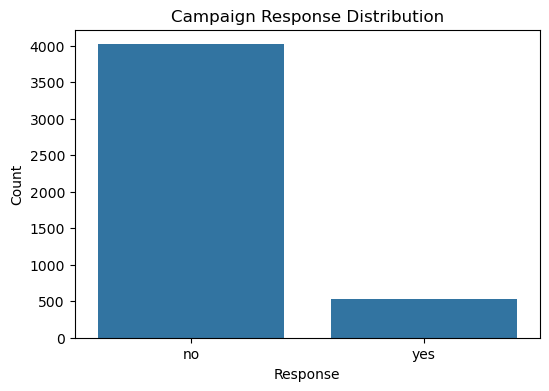

target
no     0.884658
yes    0.115342
Name: proportion, dtype: float64
age                     0
job                     0
marital                 0
education               0
default                 0
balance                 0
housing                 0
loan                    0
contact                 0
day                     0
month                   0
campaign                0
pdays                   0
previous                0
poutcome                0
target                  0
post_campaign_action    0
dtype: int64


In [19]:
plot_target_distribution(df)

df = clean_data(df)


## Feature Enginnering

In [ ]:
#time of month

def month_phase(day):
    if day <= 10:
        return "early_month"
    elif day <= 20:
        return "mid_month"
    else:
        return "late_month"

df["month_phase"] = df["day"].apply(month_phase)

#qurater of the year 
month_map = {
    "jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
    "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12
}

df["month_num"] = df["month"].map(month_map)

#season

def season(m):
    if m in [12,1,2]:
        return "summer"
    elif m in [3,4,5]:
        return "autumn"
    elif m in [6,7,8]:
        return "winter"
    else:
        return "spring"

df["season"] = df["month_num"].apply(season)
## week of month

df["week_of_month"] = (df["day"] // 7) + 1

## has customer ever been contracted 
df["previous_contact"] = df["pdays"].apply(lambda x: 0 if x == -1 else 1)

###
def recency_bucket(x):
    if x == -1:
        return "never_contacted"
    elif x <= 30:
        return "recent"
    elif x <= 180:
        return "mid_term"
    else:
        return "long_ago"

df["contact_recency"] = df["pdays"].apply(recency_bucket)

## previous contact success has 
# Customers who accepted a deposit before are much more likely to accept again.
df["previous_success"] = ((df["previous"] > 0) & (df["poutcome"] == "success")).astype(int)
## marketing pressure 
#Too many calls → customer annoyed
df["total_contacts"] = df["campaign"] + df["previous"]
# Customers are more likely to take up product 
df["salary_window"] = df["day"].apply(lambda x: 1 if x <= 7 else 0)

# Financial Stability Indicator
df["financial_pressure"] = (
    (df["housing"] == "yes").astype(int) +
    (df["loan"] == "yes").astype(int)
)

# customers likely to update products when they are liquid
def salary_cycle(day):
    if day <= 5:
        return "month_start"
    elif day <= 15:
        return "mid_month"
    elif day <= 25:
        return "pre_payday"
    else:
        return "post_payday"

df["salary_cycle"] = df["day"].apply(salary_cycle)
## reaching customers on cellphone is much easier than with a phone 
df["mobile_contact"] = (df["contact"] == "cellular").astype(int)
contact_map = {
    "cellular": 2,
    "telephone": 1,
    "unknown": 0
}

df["contact_quality"] = df["contact"].map(contact_map)

# combine campaign pressure with contact method
df["cellular_high_campaign"] = (
    (df["contact"] == "cellular") & (df["campaign"] > 3)
).astype(int)

# how long calls last compare to number of attempts
#df["call_efficiency"] = df["duration"] / (df["campaign"] + 1)

#Mobile users often indicate digital engagement.
df["digital_customer"] = (df["contact"] == "cellular").astype(int)

## life stage features 
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,40,50,60,100],
    labels=["young","early_career","mid_career","late_career","senior"]
)
# financial maturity
df["financial_maturity"] = (df["age"] >= 35).astype(int)

## job stability features
df["job"].unique()

def job_stability(job):
    
    if job in ["management","technician","admin.","retired"]:
        return "stable"
    
    elif job in ["services","blue-collar","self-employed","entrepreneur","housemaid"]:
        return "variable"
    
    else:
        return "unstable"


df["job_stability"] = df["job"].apply(job_stability)

stability_map = {
    "stable":2,
    "variable":1,
    "unstable":0
}

df["job_stability_score"] = df["job_stability"].map(stability_map)

# education
#People with tertiary education often have higher income and are more familiar with financial products.
edu_map = {
    "unknown":0,
    "primary":1,
    "secondary":2,
    "tertiary":3
}

df["education_level"] = df["education"].map(edu_map)

## marital status
#Higher values may indicate greater financial planning needs.

df["family_commitment"] = df["marital"].map({
    "single":0,
    "divorced":1,
    "married":2
})

# These customers are often good targets for savings products.
df["financial_maturity"] = (
    (df["education_level"] >= 2) &
    (df["marital"] == "married")
).astype(int)

## life stage 
df["life_stage_maturity"] = (
    (df["age"] >= 35) &
    (df["education"].isin(["secondary","tertiary"])) &
    (df["marital"] == "married")
).astype(int)

def life_stage(row):
    
    if row["age"] < 30:
        return "early_career"
    
    elif row["age"] < 45 and row["marital"] == "married":
        return "family_builder"
    
    elif row["age"] >= 45:
        return "wealth_accumulation"
    
    else:
        return "mid_career"

df["life_stage"] = df.apply(life_stage, axis=1)

## balances 
import numpy as np

df["balance_shifted"] = df["balance"] - df["balance"].min() + 1
df["log_balance"] = np.log(df["balance_shifted"])

#create balance segment

df["balance_segment"] = pd.qcut(
    df["balance"],
    q=4,
    labels=["very_low","low","medium","high"]
)

# liquidity pressure form balance and debt
df["liquidity_pressure"] = (
    (df["balance"] < 500) &
    ((df["housing"] == "yes") | (df["loan"] == "yes"))
).astype(int)

## customer waelth signals 
#high balance clients 
df["high_balance"] = (df["balance"] > df["balance"].quantile(0.75)).astype(int)
# negative balance clients
df["negative_balance"] = (df["balance"] < 0).astype(int)
#financial satbility relative to campaign effort
df["balance_per_contact"] = df["balance"] / (df["campaign"] + 1)

## customer stability
df["is_married"] = (df["marital"] == "married").astype(int)
df["stability_score"] = (
    df["job_stability_score"] +
    df["education_level"] +
    df["is_married"]
)

df["stability_score"] = (
    df["job_stability_score"] +
    df["education_level"] +
    df["is_married"]
)

## payday call
df["payday_call"] = (
    (df["day"] >= 23) | (df["day"] <= 3)
).astype(int)

# customer default and credit
df["credit_risk"] = (
    (df["default"] == 1) |
    (df["negative_balance"] == 1) |
    (df["financial_pressure"] == 1)
).astype(int)

## credit stress 
df["housing_bin"] = df["housing"].map({"yes": 1, "no": 0})
df["loan_bin"] = df["loan"].map({"yes": 1, "no": 0})

df["credit_stress"] = (
    df["housing_bin"] +
    df["loan_bin"] +
    df["financial_pressure"]
)

df["age_group"] = df["age_group"].cat.codes
df["balance_segment"] = df["balance_segment"].cat.codes

In [20]:
#time of month

def month_phase(day):
    if day <= 10:
        return "early_month"
    elif day <= 20:
        return "mid_month"
    else:
        return "late_month"

df["month_phase"] = df["day"].apply(month_phase)

In [21]:
#qurater of the year 
month_map = {
    "jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
    "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12
}

df["month_num"] = df["month"].map(month_map)

#season

def season(m):
    if m in [12,1,2]:
        return "summer"
    elif m in [3,4,5]:
        return "autumn"
    elif m in [6,7,8]:
        return "winter"
    else:
        return "spring"

df["season"] = df["month_num"].apply(season)
## week of month

df["week_of_month"] = (df["day"] // 7) + 1



In [22]:
## has customer ever been contracted 
df["previous_contact"] = df["pdays"].apply(lambda x: 0 if x == -1 else 1)

In [23]:
###
def recency_bucket(x):
    if x == -1:
        return "never_contacted"
    elif x <= 30:
        return "recent"
    elif x <= 180:
        return "mid_term"
    else:
        return "long_ago"

df["contact_recency"] = df["pdays"].apply(recency_bucket)

In [24]:
## previous contact success has 
# Customers who accepted a deposit before are much more likely to accept again.
df["previous_success"] = ((df["previous"] > 0) & (df["poutcome"] == "success")).astype(int)

In [25]:
# how long client stays on a call can be a good predictor if the client is more likely to tak up campaign or nor
#feature useful for eda
'''
def duration_bucket(x):
    if x < 60:
        return "very_short"
    elif x < 180:
        return "medium"
    else:
        return "long"

df["duration_bucket"] = df["duration"].apply(duration_bucket)
'''

'\ndef duration_bucket(x):\n    if x < 60:\n        return "very_short"\n    elif x < 180:\n        return "medium"\n    else:\n        return "long"\n\ndf["duration_bucket"] = df["duration"].apply(duration_bucket)\n'

In [26]:
## marketing pressure 
#Too many calls → customer annoyed
df["total_contacts"] = df["campaign"] + df["previous"]

In [27]:
# Customers are more likely to take up product 
df["salary_window"] = df["day"].apply(lambda x: 1 if x <= 7 else 0)

In [28]:
# Financial Stability Indicator
df["financial_pressure"] = (
    (df["housing"] == "yes").astype(int) +
    (df["loan"] == "yes").astype(int)
)

In [29]:
# customers likely to update products when they are liquid
def salary_cycle(day):
    if day <= 5:
        return "month_start"
    elif day <= 15:
        return "mid_month"
    elif day <= 25:
        return "pre_payday"
    else:
        return "post_payday"

df["salary_cycle"] = df["day"].apply(salary_cycle)

In [30]:
## reaching customers on cellphone is much easier than with a phone 
df["mobile_contact"] = (df["contact"] == "cellular").astype(int)
contact_map = {
    "cellular": 2,
    "telephone": 1,
    "unknown": 0
}

df["contact_quality"] = df["contact"].map(contact_map)

In [31]:
# combine campaign pressure with contact method
df["cellular_high_campaign"] = (
    (df["contact"] == "cellular") & (df["campaign"] > 3)
).astype(int)

In [32]:
# how long calls last compare to number of attempts
#df["call_efficiency"] = df["duration"] / (df["campaign"] + 1)

#Mobile users often indicate digital engagement.
df["digital_customer"] = (df["contact"] == "cellular").astype(int)

In [33]:
## life stage features 
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,40,50,60,100],
    labels=["young","early_career","mid_career","late_career","senior"]
)
# financial maturity
df["financial_maturity"] = (df["age"] >= 35).astype(int)

In [34]:
## job stability features
df["job"].unique()

array(['unemployed', 'services', 'management', 'blue-collar',
       'self-employed', 'technician', 'entrepreneur', 'admin.', 'student',
       'housemaid', 'retired', 'unknown'], dtype=object)

In [35]:
def job_stability(job):
    
    if job in ["management","technician","admin.","retired"]:
        return "stable"
    
    elif job in ["services","blue-collar","self-employed","entrepreneur","housemaid"]:
        return "variable"
    
    else:
        return "unstable"


df["job_stability"] = df["job"].apply(job_stability)

stability_map = {
    "stable":2,
    "variable":1,
    "unstable":0
}

df["job_stability_score"] = df["job_stability"].map(stability_map)

In [36]:
# education
#People with tertiary education often have higher income and are more familiar with financial products.
edu_map = {
    "unknown":0,
    "primary":1,
    "secondary":2,
    "tertiary":3
}

df["education_level"] = df["education"].map(edu_map)

In [37]:
## marital status
#Higher values may indicate greater financial planning needs.

df["family_commitment"] = df["marital"].map({
    "single":0,
    "divorced":1,
    "married":2
})

# These customers are often good targets for savings products.
df["financial_maturity"] = (
    (df["education_level"] >= 2) &
    (df["marital"] == "married")
).astype(int)

## life stage 
df["life_stage_maturity"] = (
    (df["age"] >= 35) &
    (df["education"].isin(["secondary","tertiary"])) &
    (df["marital"] == "married")
).astype(int)

def life_stage(row):
    
    if row["age"] < 30:
        return "early_career"
    
    elif row["age"] < 45 and row["marital"] == "married":
        return "family_builder"
    
    elif row["age"] >= 45:
        return "wealth_accumulation"
    
    else:
        return "mid_career"

df["life_stage"] = df.apply(life_stage, axis=1)

In [38]:
df["balance"].describe()

count     4543.000000
mean      1406.139115
std       3006.759038
min      -3313.000000
25%         76.000000
50%        445.000000
75%       1427.000000
max      71188.000000
Name: balance, dtype: float64

In [39]:
## balances 
import numpy as np

df["balance_shifted"] = df["balance"] - df["balance"].min() + 1
df["log_balance"] = np.log(df["balance_shifted"])

#create balance segment

df["balance_segment"] = pd.qcut(
    df["balance"],
    q=4,
    labels=["very_low","low","medium","high"]
)

# liquidity pressure form balance and debt
df["liquidity_pressure"] = (
    (df["balance"] < 500) &
    ((df["housing"] == "yes") | (df["loan"] == "yes"))
).astype(int)

In [40]:
#df.columns

In [41]:
## customer waelth signals 
#high balance clients 
df["high_balance"] = (df["balance"] > df["balance"].quantile(0.75)).astype(int)
# negative balance clients
df["negative_balance"] = (df["balance"] < 0).astype(int)
#financial satbility relative to campaign effort
df["balance_per_contact"] = df["balance"] / (df["campaign"] + 1)

In [42]:
## customer stability
df["is_married"] = (df["marital"] == "married").astype(int)
df["stability_score"] = (
    df["job_stability_score"] +
    df["education_level"] +
    df["is_married"]
)

df["stability_score"] = (
    df["job_stability_score"] +
    df["education_level"] +
    df["is_married"]
)

In [43]:
## payday call
df["payday_call"] = (
    (df["day"] >= 23) | (df["day"] <= 3)
).astype(int)

In [44]:
# customer default and credit
df["credit_risk"] = (
    (df["default"] == 1) |
    (df["negative_balance"] == 1) |
    (df["financial_pressure"] == 1)
).astype(int)

In [45]:
## credit stress 
df["housing_bin"] = df["housing"].map({"yes": 1, "no": 0})
df["loan_bin"] = df["loan"].map({"yes": 1, "no": 0})

df["credit_stress"] = (
    df["housing_bin"] +
    df["loan_bin"] +
    df["financial_pressure"]
)

In [46]:
## marketing effeinciency 
#df["marketing_efficiency"] = df["duration"] / (df["campaign"] + 1)

In [47]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'target', 'post_campaign_action', 'month_phase',
       'month_num', 'season', 'week_of_month', 'previous_contact',
       'contact_recency', 'previous_success', 'total_contacts',
       'salary_window', 'financial_pressure', 'salary_cycle', 'mobile_contact',
       'contact_quality', 'cellular_high_campaign', 'digital_customer',
       'age_group', 'financial_maturity', 'job_stability',
       'job_stability_score', 'education_level', 'family_commitment',
       'life_stage_maturity', 'life_stage', 'balance_shifted', 'log_balance',
       'balance_segment', 'liquidity_pressure', 'high_balance',
       'negative_balance', 'balance_per_contact', 'is_married',
       'stability_score', 'payday_call', 'credit_risk', 'housing_bin',
       'loan_bin', 'credit_stress'],
      dtype='object')

In [48]:
df.dtypes

age                          int64
job                         object
marital                     object
education                   object
default                     object
balance                    float64
housing                     object
loan                        object
contact                     object
day                          int64
month                       object
campaign                     int64
pdays                        int64
previous                     int64
poutcome                    object
target                      object
post_campaign_action         int64
month_phase                 object
month_num                    int64
season                      object
week_of_month                int64
previous_contact             int64
contact_recency             object
previous_success             int64
total_contacts               int64
salary_window                int64
financial_pressure           int64
salary_cycle                object
mobile_contact      

In [49]:
df["age_group"] = df["age_group"].cat.codes
df["balance_segment"] = df["balance_segment"].cat.codes

## Encoding 

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

def encode_features(df):

    df = df.copy()

    # ----------------------------------
    # Encode Target
    # ----------------------------------

    if df["target"].dtype == "object":
        df["target"] = df["target"].map({"yes":1, "no":0})


    # ----------------------------------
    # Binary Encoding
    # ----------------------------------

    binary_cols = ["housing", "loan", "default"]

    for col in binary_cols:
        if col in df.columns and df[col].dtype == "object":
            df[col] = df[col].map({"yes":1, "no":0})


    # ----------------------------------
    # Ordinal Encoding
    # ----------------------------------

    ordinal_cols = [
        "education",
        "age_group",
        "balance_segment",
        "month_phase"
    ]

    ordinal_cols = [c for c in ordinal_cols if c in df.columns]

    oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    df[ordinal_cols] = oe.fit_transform(df[ordinal_cols])


    # ----------------------------------
    # One Hot Encoding
    # ----------------------------------

    nominal_cols = [
        "job",
        "marital",
        "contact",
        "month",
        "poutcome",
        "salary_cycle",
        "job_stability",
        "life_stage",
        "season",
        "contact_recency"
    ]

    nominal_cols = [c for c in nominal_cols if c in df.columns]

    df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

    return df


# features and target
X = df.drop("target", axis=1)
y = df["target"]

# stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

def encode_features(df):

    df = df.copy()

    # ----------------------------------
    # Encode Target
    # ----------------------------------

    if df["target"].dtype == "object":
        df["target"] = df["target"].map({"yes":1, "no":0})


    # ----------------------------------
    # Binary Encoding
    # ----------------------------------

    binary_cols = ["housing", "loan", "default"]

    for col in binary_cols:
        if col in df.columns and df[col].dtype == "object":
            df[col] = df[col].map({"yes":1, "no":0})


    # ----------------------------------
    # Ordinal Encoding
    # ----------------------------------

    ordinal_cols = [
        "education",
        "age_group",
        "balance_segment",
        "month_phase"
    ]

    ordinal_cols = [c for c in ordinal_cols if c in df.columns]

    oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    df[ordinal_cols] = oe.fit_transform(df[ordinal_cols])


    # ----------------------------------
    # One Hot Encoding
    # ----------------------------------

    nominal_cols = [
        "job",
        "marital",
        "contact",
        "month",
        "poutcome",
        "salary_cycle",
        "job_stability",
        "life_stage",
        "season",
        "contact_recency"
    ]

    nominal_cols = [c for c in nominal_cols if c in df.columns]

    df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

    return df

In [51]:
df = encode_features(df)

In [52]:
df.dtypes

age                                  int64
education                          float64
default                              int64
balance                            float64
housing                              int64
                                    ...   
season_summer                         bool
season_winter                         bool
contact_recency_mid_term              bool
contact_recency_never_contacted       bool
contact_recency_recent                bool
Length: 87, dtype: object

## Split Data

In [53]:

# features and target
X = df.drop("target", axis=1)
y = df["target"]

# stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (3634, 86)
Test shape: (909, 86)

Train class distribution:
target
0    0.8847
1    0.1153
Name: proportion, dtype: float64

Test class distribution:
target
0    0.884488
1    0.115512
Name: proportion, dtype: float64


## Scale data

In [54]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model training 

In [ ]:
## stratified k fold to train model since data is imbalance 
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
## define models
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

log_cv_scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression CV AUC:", log_cv_scores)
print("Logistic Regression Mean CV AUC:", log_cv_scores.mean())

print("\nRandom Forest CV AUC:", rf_cv_scores)
print("Random Forest Mean CV AUC:", rf_cv_scores.mean())

print("\nXGBoost CV AUC:", xgb_cv_scores)
print("XGBoost Mean CV AUC:", xgb_cv_scores.mean())

# trained model fit 
log_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# evaluate test 
def evaluate_model(name, model, X_test_data, y_test):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("ROC AUC:", roc_auc_score(y_test, y_prob))

# evaluate model
evaluate_model("Logistic Regression", log_model, X_test_scaled, y_test)
evaluate_model("Random Forest", rf_model, X_test, y_test)
evaluate_model("XGBoost", xgb_model, X_test, y_test)

## compare models 
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Mean_CV_AUC": [
        log_cv_scores.mean(),
        rf_cv_scores.mean(),
        xgb_cv_scores.mean()
    ]
})

results = results.sort_values("Mean_CV_AUC", ascending=False)
print(results)

In [58]:
## stratified k fold to train model since data is imbalance 
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [59]:
## define models
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [60]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

scale_pos_weight: 7.673031026252984


In [61]:
log_cv_scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression CV AUC:", log_cv_scores)
print("Logistic Regression Mean CV AUC:", log_cv_scores.mean())

print("\nRandom Forest CV AUC:", rf_cv_scores)
print("Random Forest Mean CV AUC:", rf_cv_scores.mean())

print("\nXGBoost CV AUC:", xgb_cv_scores)
print("XGBoost Mean CV AUC:", xgb_cv_scores.mean())

Logistic Regression CV AUC: [0.75099978 0.73720655 0.74679701 0.77268015 0.79398152]
Logistic Regression Mean CV AUC: 0.7603330005201878

Random Forest CV AUC: [0.76186773 0.75414723 0.73892839 0.78619566 0.77799846]
Random Forest Mean CV AUC: 0.7638274939348596

XGBoost CV AUC: [0.76447826 0.72606088 0.7433163  0.75781308 0.78999044]
XGBoost Mean CV AUC: 0.7563317923995471


In [62]:
# trained model fit 
log_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [63]:
# evaluate test 
def evaluate_model(name, model, X_test_data, y_test):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("ROC AUC:", roc_auc_score(y_test, y_prob))

In [64]:
# evaluate model
evaluate_model("Logistic Regression", log_model, X_test_scaled, y_test)
evaluate_model("Random Forest", rf_model, X_test, y_test)
evaluate_model("XGBoost", xgb_model, X_test, y_test)


Logistic Regression
Confusion Matrix:
[[574 230]
 [ 32  73]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.71      0.81       804
           1       0.24      0.70      0.36       105

    accuracy                           0.71       909
   macro avg       0.59      0.70      0.59       909
weighted avg       0.87      0.71      0.76       909

ROC AUC: 0.7788438758588012

Random Forest
Confusion Matrix:
[[741  63]
 [ 61  44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       804
           1       0.41      0.42      0.42       105

    accuracy                           0.86       909
   macro avg       0.67      0.67      0.67       909
weighted avg       0.86      0.86      0.86       909

ROC AUC: 0.7667851220090025

XGBoost
Confusion Matrix:
[[710  94]
 [ 56  49]]

Classification Report:
              precision    recall  f1-score   supp

In [65]:
## compare models 
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Mean_CV_AUC": [
        log_cv_scores.mean(),
        rf_cv_scores.mean(),
        xgb_cv_scores.mean()
    ]
})

results = results.sort_values("Mean_CV_AUC", ascending=False)
print(results)

                 Model  Mean_CV_AUC
1        Random Forest     0.763827
0  Logistic Regression     0.760333
2              XGBoost     0.756332


## Feature Importance 

In [ ]:
coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_model.coef_[0]
})

coefficients = coefficients.sort_values("coefficient", ascending=False)

print(coefficients.head(15))

positive_drivers = coefficients.head(10)
print(positive_drivers)

negative_drivers = coefficients.tail(10)
print(negative_drivers)

import matplotlib.pyplot as plt

top_features = pd.concat([
    coefficients.head(8),
    coefficients.tail(8)
])

plt.figure(figsize=(8,6))

plt.barh(top_features["feature"], top_features["coefficient"])

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient Value")

plt.axvline(0, color="black")

plt.show()

# sort responders in deciles by predicted probability of response
# Decile 9 represents customers most likely to repond and 0 customers less likely to reapond 

results = pd.DataFrame({
    "probability": log_model.predict_proba(X_test_scaled)[:,1],
    "actual": y_test
})

# sort by predicted probability
results = results.sort_values("probability", ascending=False)

# create deciles based on probability
results["decile"] = pd.qcut(results["probability"], 10, labels=False)

# calculate response rate
decile_response = results.groupby("decile")["actual"].mean()

print(decile_response)

## Overall uptake rate 
def uptake_rate(percent):

    cutoff = int(len(results) * percent)

    subset = results.head(cutoff)

    return subset["actual"].mean()

print("Top 10% uptake:", uptake_rate(0.10))
print("Top 20% uptake:", uptake_rate(0.20))
print("Top 30% uptake:", uptake_rate(0.30))

In [70]:
coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_model.coef_[0]
})

coefficients = coefficients.sort_values("coefficient", ascending=False)

print(coefficients.head(15))

                     feature  coefficient
10      post_campaign_action     0.611278
6                        day     0.448878
31           balance_segment     0.340155
71          poutcome_unknown     0.251170
24        financial_maturity     0.214479
15          previous_success     0.213679
70          poutcome_success     0.213679
67                 month_oct     0.212105
72  salary_cycle_month_start     0.177336
8                      pdays     0.144936
34          negative_balance     0.141749
0                        age     0.130146
64                 month_mar     0.118709
47               job_retired     0.118539
32        liquidity_pressure     0.112466


In [71]:
positive_drivers = coefficients.head(10)
print(positive_drivers)

                     feature  coefficient
10      post_campaign_action     0.611278
6                        day     0.448878
31           balance_segment     0.340155
71          poutcome_unknown     0.251170
24        financial_maturity     0.214479
15          previous_success     0.213679
70          poutcome_success     0.213679
67                 month_oct     0.212105
72  salary_cycle_month_start     0.177336
8                      pdays     0.144936


In [72]:
negative_drivers = coefficients.tail(10)
print(negative_drivers)

                           feature  coefficient
17                   salary_window    -0.152360
39                     credit_risk    -0.153929
61                       month_jan    -0.175683
74         salary_cycle_pre_payday    -0.182764
28             life_stage_maturity    -0.195840
77       life_stage_family_builder    -0.209684
78           life_stage_mid_career    -0.269175
79  life_stage_wealth_accumulation    -0.276300
65                       month_may    -0.285456
73        salary_cycle_post_payday    -0.410410


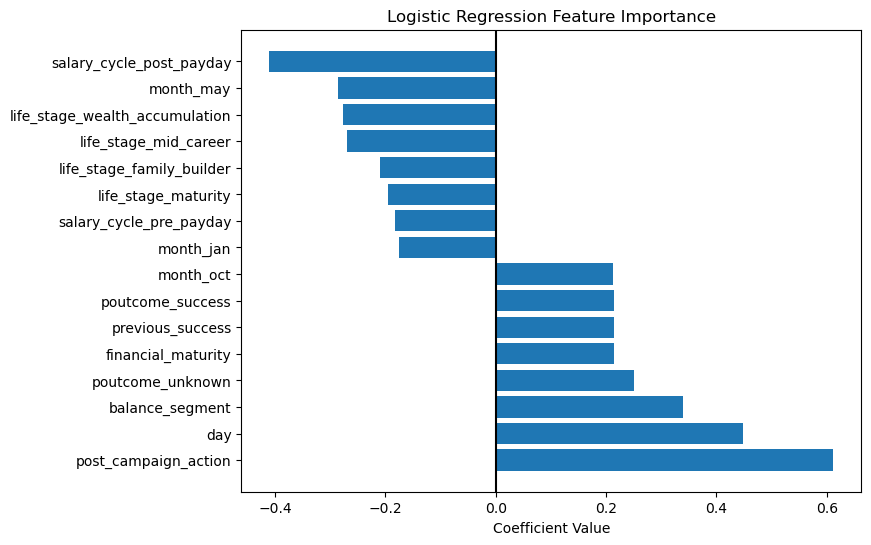

In [73]:
import matplotlib.pyplot as plt

top_features = pd.concat([
    coefficients.head(8),
    coefficients.tail(8)
])

plt.figure(figsize=(8,6))

plt.barh(top_features["feature"], top_features["coefficient"])

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient Value")

plt.axvline(0, color="black")

plt.show()

## Decile analysis

In [67]:
# sort responders in deciles by predicted probability of response
# Decile 9 represents customers most likely to repond and 0 customers less likely to reapond 

results = pd.DataFrame({
    "probability": log_model.predict_proba(X_test_scaled)[:,1],
    "actual": y_test
})

# sort by predicted probability
results = results.sort_values("probability", ascending=False)

# create deciles based on probability
results["decile"] = pd.qcut(results["probability"], 10, labels=False)

# calculate response rate
decile_response = results.groupby("decile")["actual"].mean()

print(decile_response)

decile
0    0.010989
1    0.043956
2    0.021978
3    0.076923
4    0.065934
5    0.077778
6    0.098901
7    0.120879
8    0.153846
9    0.483516
Name: actual, dtype: float64


In [68]:
## Overall uptake rate 
def uptake_rate(percent):

    cutoff = int(len(results) * percent)

    subset = results.head(cutoff)

    return subset["actual"].mean()

print("Top 10% uptake:", uptake_rate(0.10))
print("Top 20% uptake:", uptake_rate(0.20))
print("Top 30% uptake:", uptake_rate(0.30))

Top 10% uptake: 0.4777777777777778
Top 20% uptake: 0.32044198895027626
Top 30% uptake: 0.2536764705882353
